In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF

In [ ]:
# Load the MNIST data
# (available from https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz)  
with np.load("../../../data/mnist.npz") as f:
    Xtrain, ytrain = f['x_train'], f['y_train']

In [28]:
# vectorize images to matrices and subsample every 10th data point to make this run faster
# normalize gray scale values to [0,1]
Xtrain0 = Xtrain.reshape(60000, -1)
X = Xtrain0[::10, :]/255.0
n, d = np.shape(X)

In [29]:
# compute SVD of the X matrix (i.e., low-rank factorization without constraints)
U, s, Vt = np.linalg.svd(X, full_matrices=False)

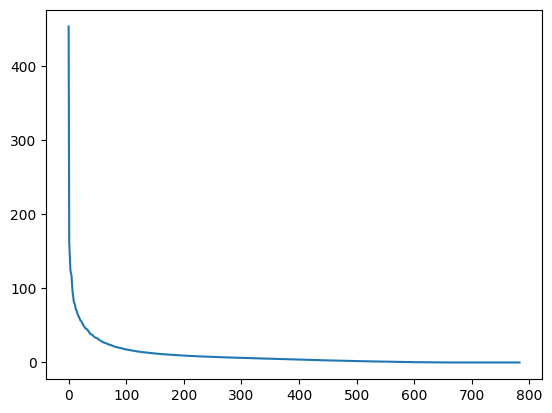

In [30]:
plt.plot(np.arange(d), s)

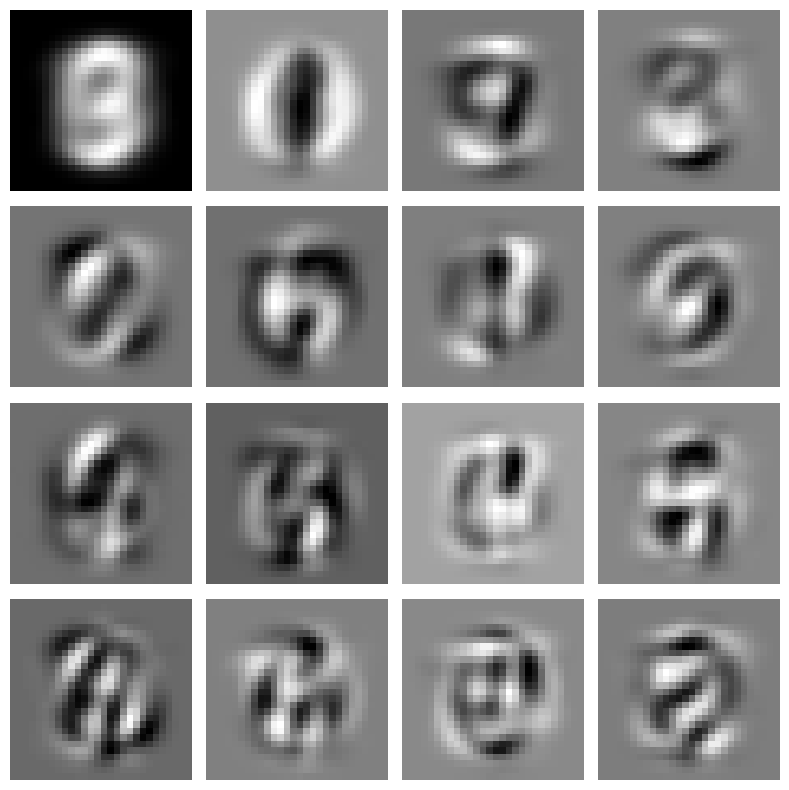

In [32]:
# the basic templates correspond to Vt: 
V = Vt.T
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(V[:,i].reshape(28, 28), cmap='gray')
    ax.axis('off')  # Hide axis ticks and labels

plt.tight_layout()
plt.show()

In [36]:
# now run a NMF 
n_components = 50
nmf_model = NMF(n_components=n_components, init='random', random_state=0, max_iter=1000)

# Fit the model to the data and transform the data
A = nmf_model.fit_transform(X)
# The components ('templates', 'patterns') are stored in nmf_model.components_ 
B = nmf_model.components_

In [39]:
np.shape(B)

(50, 784)

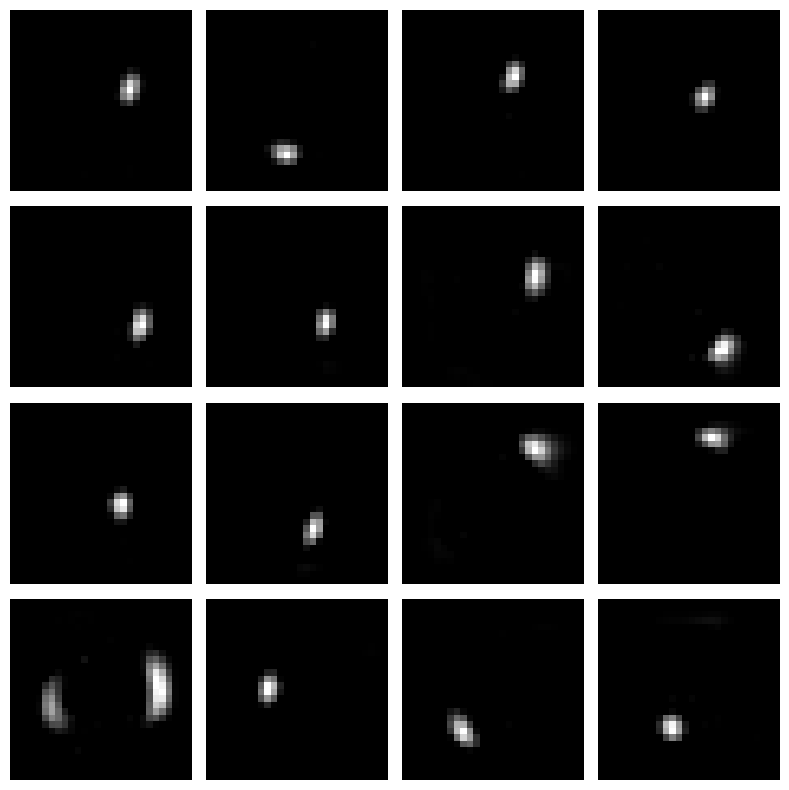

In [40]:
# plot the templates
Bt = B.T
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(Bt[:,i].reshape(28, 28), cmap='gray')
    ax.axis('off')  # Hide axis ticks and labels

plt.tight_layout()
plt.show()